In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
import keras
import tensorflow as tf

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
ipl = pd.read_csv('ipl_data.csv')
ipl.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


/tmp/ipykernel_239/1342311412.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=matches_count.values, y=matches_count.index, palette="rainbow")


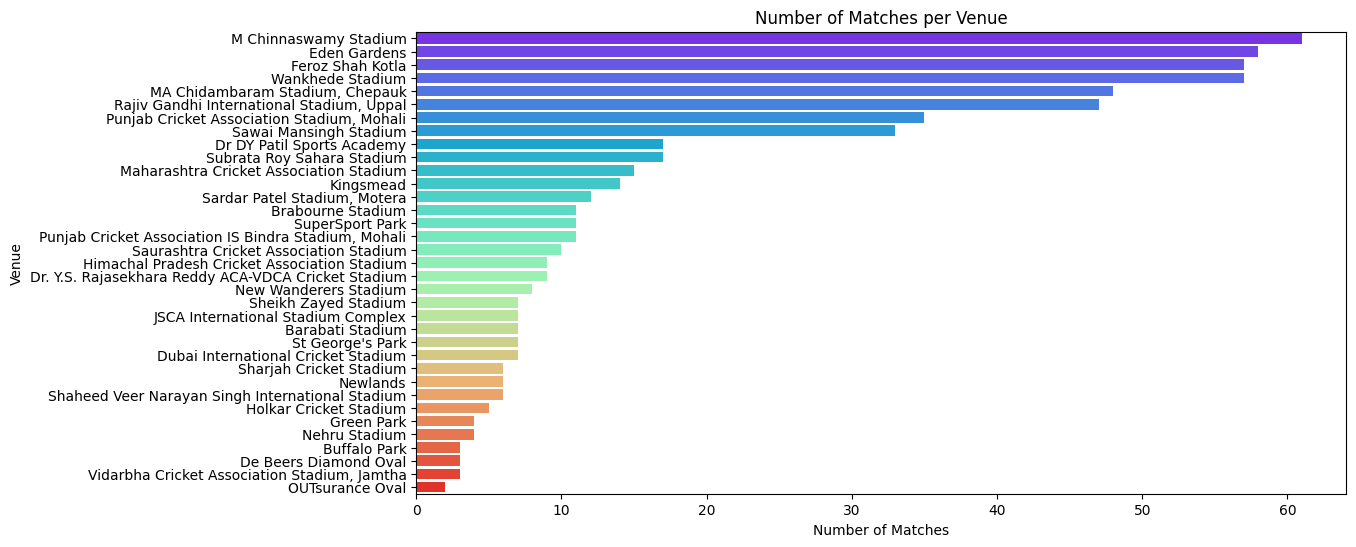

In [ ]:
# 1. Make a copy of the data so we don't accidentally ruin the original
data = ipl.copy()

# 2. Find unique matches per venue
# 'mid' stands for Match ID. A single match has hundreds of rows (one for every ball bowled).
# We use drop_duplicates() so we only count each match ONCE per stadium.
matches_per_venue = data[['mid', 'venue']].drop_duplicates()

# 3. Count them up
matches_count = matches_per_venue['venue'].value_counts()

# 4. Draw the graph using Seaborn (sns) and Matplotlib (plt)
plt.figure(figsize=(12, 6))
sns.barplot(x=matches_count.values, y=matches_count.index, palette="rainbow")
plt.title('Number of Matches per Venue')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.show()

/tmp/ipykernel_239/832246567.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=runs_by_batsman.values, y=runs_by_batsman.index, palette="pastel")


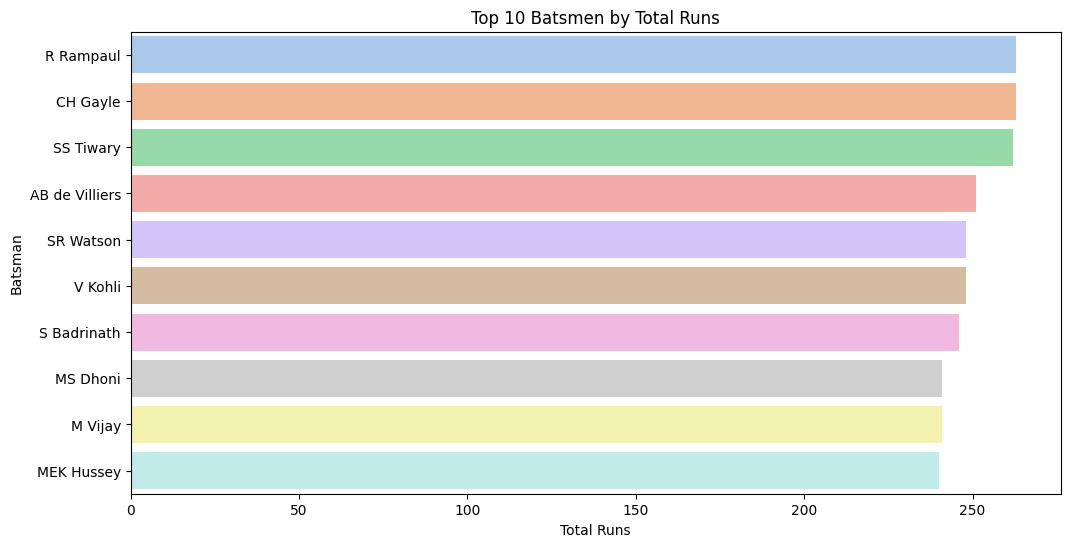

/tmp/ipykernel_239/832246567.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wickets_by_bowler.values, y=wickets_by_bowler.index, palette="muted")


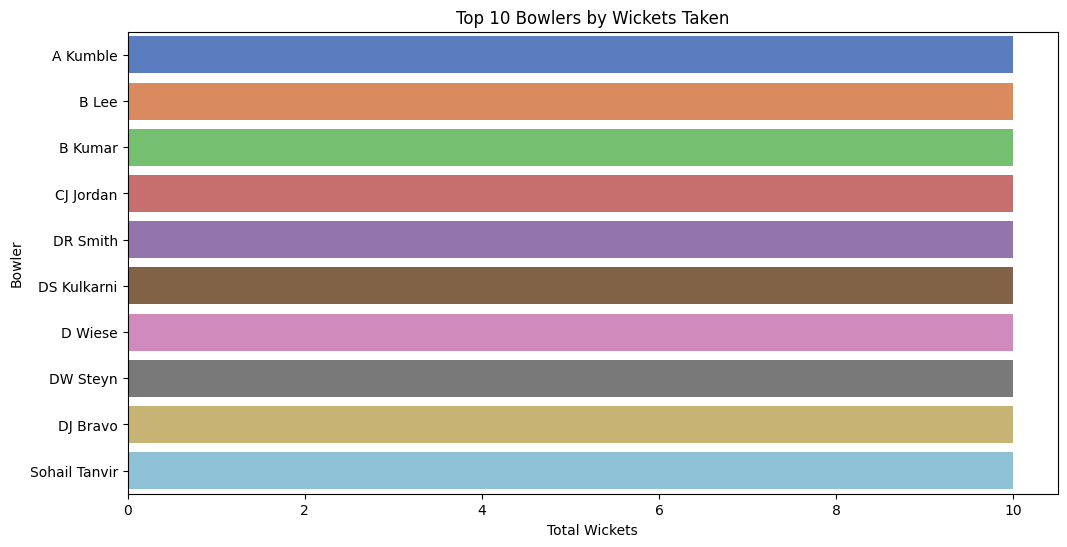

In [ ]:
# --- TOP 10 BATSMEN ---
# We group the data by 'batsman', find their max runs, sort them, and grab the top 10
runs_by_batsman = data.groupby('batsman')['runs'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=runs_by_batsman.values, y=runs_by_batsman.index, palette="pastel")
plt.title('Top 10 Batsmen by Total Runs')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.show()

# --- TOP 10 BOWLERS ---
# Same logic, but grouping by 'bowler' and looking at 'wickets'
wickets_by_bowler = data.groupby('bowler')['wickets'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=wickets_by_bowler.values, y=wickets_by_bowler.index, palette="muted")
plt.title('Top 10 Bowlers by Wickets Taken')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# These are the columns that contain text instead of numbers
cat_cols = ['bat_team', 'bowl_team', 'venue', "batsman", "bowler"]

data_encoded = data.copy()
label_encoders = {} # We save the encoders here so we can translate numbers back to text later!

# Loop through each text column and convert the words to numbers
for col in cat_cols:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data_encoded[col])
    label_encoders[col] = le

print("Encoding done! Here is what the data looks like now:")
data_encoded.head()

Encoding done! Here is what the data looks like now:


,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,14,6,12,328,201,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,14,6,12,61,201,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,14,6,12,61,201,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,14,6,12,61,201,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,14,6,12,61,201,2,0,0.4,2,0,0,0,222


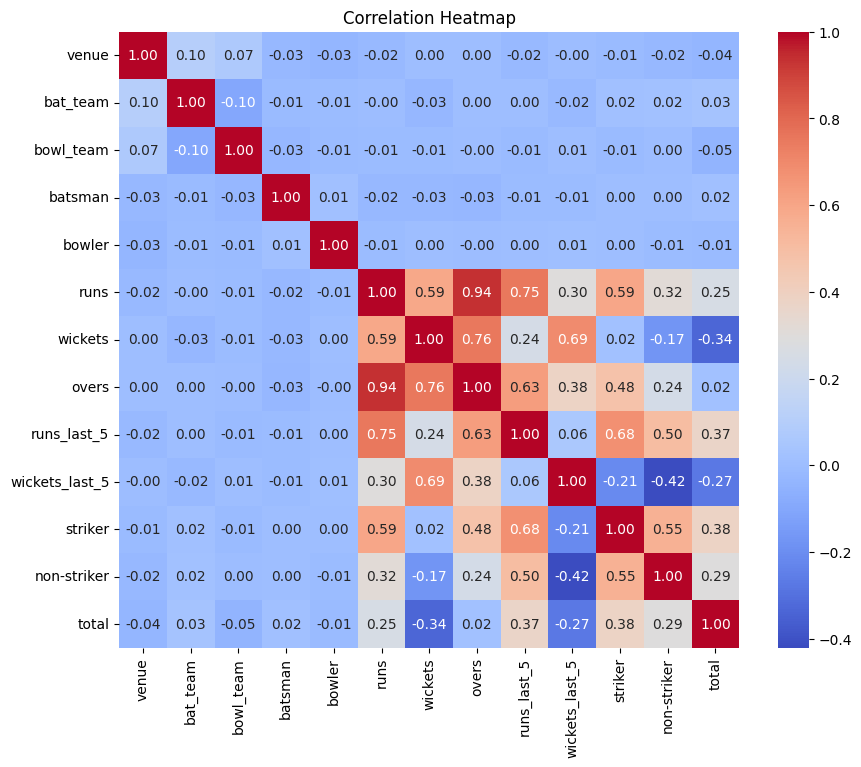

In [ ]:
# Drop the useless ID and Date columns before we do the math
data_corr = data_encoded.drop(columns=["date", "mid"], axis=1)

# Calculate the correlation and plot it as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data_corr.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# We select the features we actually want to keep (dropping the highly correlated ones)
feature_cols = ['bat_team', 'bowl_team', 'venue', 'runs', 'wickets', 'overs', 'striker', 'batsman', 'bowler']

# X = Our inputs
X = data_encoded[feature_cols]

# y = The final target score we want the AI to predict
y = data_encoded['total']

# Split the data! 70% for training, 30% for testing.
# random_state=42 just ensures we get the exact same random split every time we run this cell.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data size: {X_train.shape[0]} rows")
print(f"Testing data size: {X_test.shape[0]} rows")

Training data size: 53209 rows
Testing data size: 22805 rows


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Create the scaler tool
scaler = MinMaxScaler()

# 1. We FIT the scaler to the training data (it finds the min and max values)
# and then TRANSFORM the training data into the 0-1 scale.
X_train_scaled = scaler.fit_transform(X_train)

# 2. We ONLY transform the test data.
# We don't 'fit' it again because we want the AI to use the exact same scale it learned from the training set!
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully! Everything is between 0 and 1 now.")

Data scaled successfully! Everything is between 0 and 1 now.


In [ ]:
# Create the brain structure
model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(216, activation='relu'),
    keras.layers.Dense(1, activation='linear')
])

# Tell it how to learn
huber_loss = tf.keras.losses.Huber(delta=1.0)
model.compile(optimizer='adam', loss=huber_loss)

print("Brain successfully built! Here is the architecture summary:")
model.summary()

Brain successfully built! Here is the architecture summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 216)            │       110,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           217 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,145 (453.69 KB)

 Trainable params: 116,145 (453.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 26.9027 - val_loss: 15.0163
Epoch 2/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 14.9499 - val_loss: 14.3989
Epoch 3/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 14.6522 - val_loss: 14.5408
Epoch 4/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 14.5387 - val_loss: 14.5374
Epoch 5/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 14.4191 - val_loss: 14.2305
Epoch 6/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 14.4161 - val_loss: 14.3046
Epoch 7/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 14.2761 - val_loss: 14.3206
Epoch 8/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 14.2556 - val_loss: 13.8305
Epoch 9/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 14.2273 - val_loss: 13.7801
Epoch 10/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 14.1830 - val_loss: 13.8662


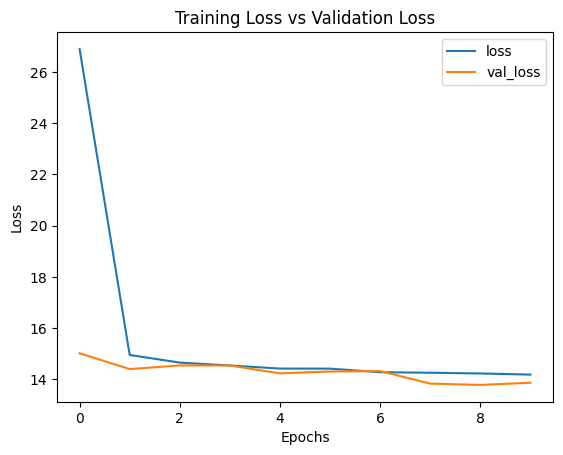

In [ ]:
# Train the model! (This might take a few seconds to run)
history = model.fit(X_train_scaled, y_train, epochs=10, batch_size=64, validation_data=(X_test_scaled, y_test))

# Plot the learning curve to see how much smarter it got over time
model_losses = pd.DataFrame(history.history)
model_losses.plot()
plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Force the model to guess the scores for the entire hidden test dataset
predictions = model.predict(X_test_scaled)

# 2. Compare its guesses to the actual real final scores
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: {mae:.2f} runs")

713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Mean Absolute Error: 14.36 runs


In [ ]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings("ignore")

# --- 1. Create the Dropdowns and Input Boxes ---
venue = widgets.Dropdown(options=list(label_encoders['venue'].classes_), description='Venue:')
batting_team = widgets.Dropdown(options=list(label_encoders['bat_team'].classes_), description='Bat Team:')
bowling_team = widgets.Dropdown(options=list(label_encoders['bowl_team'].classes_), description='Bowl Team:')
striker = widgets.Dropdown(options=list(label_encoders['batsman'].classes_), description='Striker:')
bowler = widgets.Dropdown(options=list(label_encoders['bowler'].classes_), description='Bowler:')

runs = widgets.IntText(value=50, description='Current Runs:')
wickets = widgets.IntText(value=2, description='Wickets:')
overs = widgets.FloatText(value=5.0, description='Overs:')
striker_ind = widgets.IntText(value=1, description='Striker (1/0):') # 1 if striker is batting, 0 if non-striker

predict_button = widgets.Button(description="Predict Score", button_style='success')
output = widgets.Output()

# --- 2. The Prediction Engine ---
def predict_score(b):
    with output:
        clear_output() # Clear the old prediction

        # Translate the text back into math
        encoded_venue = label_encoders['venue'].transform([venue.value])[0]
        encoded_batting_team = label_encoders['bat_team'].transform([batting_team.value])[0]
        encoded_bowling_team = label_encoders['bowl_team'].transform([bowling_team.value])[0]
        encoded_striker = label_encoders['batsman'].transform([striker.value])[0]
        encoded_bowler = label_encoders['bowler'].transform([bowler.value])[0]

        # Package the features in the EXACT order the AI learned them
        input_features = [
            encoded_batting_team,
            encoded_bowling_team,
            encoded_venue,
            runs.value,
            wickets.value,
            overs.value,
            striker_ind.value,
            encoded_striker,
            encoded_bowler
        ]

        # Scale the data and predict
        input_array = np.array(input_features).reshape(1, -1)
        input_array = scaler.transform(input_array)
        predicted_score = model.predict(input_array, verbose=0)

        print(f"🔥 PREDICTED FINAL SCORE: {int(predicted_score[0][0])} 🔥")

# --- 3. Display Everything ---
predict_button.on_click(predict_score)
display(venue, batting_team, bowling_team, striker, bowler, runs, wickets, overs, striker_ind, predict_button, output)

Dropdown(description='Venue:', options=('Barabati Stadium', 'Brabourne Stadium', 'Buffalo Park', 'De Beers Dia…

Dropdown(description='Bat Team:', options=('Chennai Super Kings', 'Deccan Chargers', 'Delhi Daredevils', 'Guja…

Dropdown(description='Bowl Team:', options=('Chennai Super Kings', 'Deccan Chargers', 'Delhi Daredevils', 'Guj…

Dropdown(description='Striker:', options=('A Ashish Reddy', 'A Chandila', 'A Chopra', 'A Choudhary', 'A Flinto…

Dropdown(description='Bowler:', options=('A Ashish Reddy', 'A Chandila', 'A Choudhary', 'A Flintoff', 'A Kumbl…

...

IntText(value=2, description='Wickets:')

FloatText(value=5.0, description='Overs:')

IntText(value=1, description='Striker (1/0):')

Button(button_style='success', description='Predict Score', style=ButtonStyle())

Output()